# Rossmann Forecasting — sklearn (lag features)

**Context.** Rossmann operates 1,115 drugstores across Germany. Planners need a sales outlook several weeks ahead to size inventory and staffing.

**Question.** Can we forecast total daily sales six weeks ahead, and does a model beat a simple rule of thumb?

**Approach.** Time series breaks two standard ML assumptions — observations aren't independent, and the train/test split can't be random. Both are solved without leaving familiar territory: a **lag feature** puts the past into a column (turning forecasting into ordinary regression), and a **chronological split** prevents look-ahead leakage. We compare Linear Regression and Random Forest against a seasonal-naive baseline.

This is the lead forecasting notebook. A companion notebook, `04_forecasting_prophet`, solves the same problem with Prophet, which needs almost no feature engineering, as a cross-check on these results.

## 1. Load and build the daily series

We start from the clean table produced by `01_etl_pipeline`, keep only **open** days (closed days are zero by definition and would distort the series), and aggregate to one row per day: total sales plus the share of stores running a promotion.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

df = pd.read_parquet("data/rossmann_clean.parquet")
df["Date"] = pd.to_datetime(df["Date"])
open_df = df[df["Open"] == 1].copy()

daily = (open_df.groupby("Date")
         .agg(y=("Sales", "sum"), PromoShare=("Promo", "mean"))
         .reset_index().rename(columns={"Date": "ds"}))

print("Days:", len(daily), "|", daily["ds"].min().date(), "->", daily["ds"].max().date())
daily.head()

Days: 942 | 2013-01-01 -> 2015-07-31


,ds,y,PromoShare
0,2013-01-01,97235,0.0
1,2013-01-02,6949829,0.0
2,2013-01-03,6347820,0.0
3,2013-01-04,6638954,0.0
4,2013-01-05,5951593,0.0


One row per day: `ds` (date), `y` (total sales — our target), and `PromoShare` (fraction of stores promoting, 0–1).


## 2. Feature engineering

A **lag feature** is a past value of the target used as an input column. This is what lets a standard regressor see history.

I use one lag, `lag_7` (same weekday last week). The EDA showed the weekly cycle is the dominant pattern, and `lag_7` captures it directly: last week's Monday is a strong predictor of this week's Monday. I don't add `lag_1` (yesterday) or `lag_14`, because the EDA didn't show a reason for them, and `lag_7` alone keeps the model simple and honest. `lag_7` is also the baseline (see below), so the model starts from the baseline and adds promo and calendar information on top.

I add **calendar** columns (`dayofweek`, `month`) so the model can learn seasonality directly, and keep `PromoShare` since promotions drive a large lift. Rows with a missing lag (the first 7 days) are dropped.

In [2]:
def make_features(data, lags=(7,)):
    d = data.copy()
    for L in lags:
        d[f"lag_{L}"] = d["y"].shift(L)
    d["dayofweek"] = d["ds"].dt.dayofweek
    d["month"] = d["ds"].dt.month
    return d.dropna().reset_index(drop=True)

feat = make_features(daily)
feature_cols = [c for c in feat.columns if c not in ("ds", "y")]
print("Features:", feature_cols)
feat.head()

Features: ['PromoShare', 'lag_7', 'dayofweek', 'month']


,ds,y,PromoShare,lag_7,dayofweek,month
0,2013-01-08,8749437,1.0,97235.0,1,1
1,2013-01-09,7746603,1.0,6949829.0,2,1
2,2013-01-10,7751485,1.0,6347820.0,3,1
3,2013-01-11,8039306,1.0,6638954.0,4,1
4,2013-01-12,6017491,0.0,5951593.0,5,1


Every row now describes recent history, the type of day, and promo activity — a normal supervised feature table.


## 3. Chronological split

The test set is the **last 42 days (6 weeks)**. Six weeks is a realistic planning horizon for inventory and staffing, and it's the horizon the original Rossmann Kaggle task used, so it's a sensible choice for this problem. Critically, the split is by position in time, never random: the model must not see any test-period day during training.

In [3]:
horizon = 42
train, test = feat.iloc[:-horizon], feat.iloc[-horizon:]
X_train, y_train = train[feature_cols], train["y"]
X_test, y_test = test[feature_cols], test["y"]
actual = y_test.values

print("Train:", train["ds"].min().date(), "->", train["ds"].max().date())
print("Test :", test["ds"].min().date(), "->", test["ds"].max().date())


Train: 2013-01-08 -> 2015-06-19
Test : 2015-06-20 -> 2015-07-31


Train ends exactly where test begins — no overlap, no leakage.


## 4. Metrics and baseline

We report three metrics:

- **MAE** — average miss in sales units.
- **RMSE** — punishes large misses harder.
- **WAPE** (weighted absolute percentage error) — total error ÷ total actual sales.

**Why WAPE rather than the more familiar MAPE?** MAPE divides each day's error by that day's actual value. This series contains public holidays where nearly every store shuts and total sales fall to ~100,000 against a normal ~7,000,000. Being off by 500,000 on such a day yields a 514% error from one observation, which swamps the mean. MAPE is unusable on any series with near-zero values. WAPE divides *summed* error by *summed* actuals, so small days can't distort it — it's the standard choice in retail forecasting.

Before modelling we establish a **baseline**: predict "same weekday last week", which is simply our `lag_7` column. Without it, an error figure says nothing about whether a model earns its complexity.

In [4]:
def mae(a, f):  return np.mean(np.abs(a - f))
def rmse(a, f): return np.sqrt(np.mean((a - f) ** 2))
# WAPE (weighted absolute percentage error) instead of MAPE — see note above.
def wape(a, f): return np.sum(np.abs(a - f)) / np.sum(np.abs(a)) * 100

snaive_pred = test["lag_7"].values
print(f"Seasonal-naive  MAE {mae(actual, snaive_pred):,.0f}  RMSE {rmse(actual, snaive_pred):,.0f}  WAPE {wape(actual, snaive_pred):.2f}%")


Seasonal-naive  MAE 2,019,637  RMSE 2,560,492  WAPE 30.17%


The baseline is off by about **30% of total sales** (WAPE), averaging ~2.0M per day. That's the bar to beat — not a low error, so there's real room for a model to add value.

## 5. Models

With the series reshaped into a feature table, forecasting is ordinary regression. I fit three models:

- **Linear Regression (integer weekday/month)** — the simplest encoding.
- **Linear Regression (one-hot weekday/month)** — feeds `dayofweek` and `month` as separate categories, the encoding notebook 02 committed to. This lets me test whether that encoding actually helps once `lag_7` is already in the model.
- **Random Forest** — captures non-linear interactions (e.g. promo effects varying by weekday) with no encoding choice needed.

`lag_7` and `PromoShare` stay numeric throughout; only the two calendar columns are one-hot encoded.

**A note on scaling.** `PromoShare` (0–1) and `lag_7` (~100k–7M) live on very different scales, so it's tempting to standardize them. I don't, for two reasons. Ordinary least squares is scale-invariant: rescaling a feature just rescales its coefficient inversely and changes no prediction, so it wouldn't move any score here. And leaving the features in natural units keeps the coefficients readable. The one cost is that the raw coefficients below can't be compared directly to judge "which feature matters more", so I read each in its own units instead. Scaling would only become necessary with a regularized model like Ridge or Lasso, which penalize large coefficients and so need comparable scales.

In [5]:
# Integer-encoded linear (the diagnostic version)
lin = LinearRegression().fit(X_train, y_train)
lin_pred = lin.predict(X_test)

# One-hot linear: the encoding notebook 02 committed to.
# lag_7 + PromoShare pass through as numbers; dayofweek + month become 0/1 category columns.
numeric_cols = ["lag_7", "PromoShare"]
categorical_cols = ["dayofweek", "month"]
pre = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])
lin_oh = Pipeline([("pre", pre), ("reg", LinearRegression())]).fit(X_train, y_train)
lin_oh_pred = lin_oh.predict(X_test)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results = pd.DataFrame(
    {name: [mae(actual, p), rmse(actual, p), wape(actual, p)]
     for name, p in [("Seasonal-naive", snaive_pred),
                     ("Linear (integer)", lin_pred),
                     ("Linear (one-hot)", lin_oh_pred),
                     ("Random Forest", rf_pred)]},
    index=["MAE", "RMSE", "WAPE"],
).T.round(2)
results

,MAE,RMSE,WAPE
Seasonal-naive,2019637.26,2560492.36,30.17
Linear (integer),1009442.49,1229624.19,15.08
Linear (one-hot),1950941.41,2349546.66,29.15
Random Forest,598295.47,907478.09,8.94


Reading the table against the baseline (WAPE 30.2%):

- **Linear (integer)** halves the baseline to **15.1%**.
- **Linear (one-hot)** is **29.15%**, barely better than the baseline and clearly *worse* than the integer version.
- **Random Forest** wins decisively at **8.9%**, cutting the baseline to under a third.

The one-hot result is the interesting one, and not what I expected. Notebook 02 said to feed weekday and month as categories, and I did. But one-hot made the linear model *worse*, not better. The coefficient cells below show why: `lag_7` is "last week's same weekday", so it already carries the weekly shape. Once lag_7 is in the model, the explicit weekday categories are redundant, they end up near zero, and the ~17 extra category columns just add noise on a 42-day holdout. So here the two things 02 recommended, `lag_7` and categorical weekday, overlap: lag_7 gets there first and the encoding choice stops mattering for the linear model.

Random Forest sidesteps all of this. It captures the promo × weekday interaction (+57% Monday → +22% Friday) that no additive linear model can, whatever the encoding, which is why it leads.

First the integer model's coefficients. Each is the change in predicted sales per one-unit change in that feature, holding the others fixed.

In [6]:
coef = pd.Series(lin.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
print(coef.round(2))


PromoShare    3364456.39
dayofweek     -212130.77
month          -13966.62
lag_7               0.44
dtype: float64


The integer model beats the baseline clearly, and its coefficients read cleanly:

- **`PromoShare` ≈ +3.36M** — the full swing from no stores promoting to all promoting. Large and positive, consistent with the EDA's ~+39% lift.
- **`lag_7` ≈ 0.44** — real positive weight: last week's same weekday carries most of the signal, and with no other lag it does that work alone.
- **`dayofweek` ≈ −212,131** — a single negative slope across the week. As an *integer* (0=Mon … 6=Sun), weekday can only shift sales by a fixed amount per step. Sales do fall from Monday toward the weekend, so that slope isn't hopeless, but it can't capture the one feature that matters most: the Sunday cliff, where the total collapses to near-zero because almost all stores shut. A fixed per-step slope can't size a drop that large at a single point.
- **`month` ≈ −14k** — small compared with the `dayofweek` coefficient, exactly as the EDA predicted: the yearly signal is weak and December is its only strong move. And this test window is entirely June–July, so it doesn't even contain December, month can't show its one real effect on this particular holdout.

In [7]:
# Per-weekday coefficients from the one-hot model: does it recover the real weekly shape?
ohe = lin_oh.named_steps["pre"].named_transformers_["cat"]
ohe_names = list(ohe.get_feature_names_out(categorical_cols))
all_names = numeric_cols + ohe_names
coefs = dict(zip(all_names, lin_oh.named_steps["reg"].coef_))
print("One-hot weekday coefficients (dropped day = baseline = 0):")
for name in ohe_names:
    if name.startswith("dayofweek_"):
        print(f"  {name:14s} {coefs[name]:>12,.0f}")

One-hot weekday coefficients (dropped day = baseline = 0):
  dayofweek_1               0
  dayofweek_2               0
  dayofweek_3               0
  dayofweek_4               0
  dayofweek_5               0
  dayofweek_6              -0


These are the payoff, and they need reading honestly. Every weekday coefficient prints as essentially **zero**. My read on why: `lag_7` is last week's value of *this same weekday*, so it already carries the weekly shape (last Monday was high, so lag_7 is high on Mondays). Once lag_7 is in the model, the one-hot weekday flags have almost nothing left to explain, so they get near-zero weight. I think that redundancy is also why the one-hot model scored *worse* than the integer one: the ~17 flag coefficients are near-zero but each carries a little estimation noise, and on a 42-day test window that noise costs more than the flags add.

I want to be careful not to overclaim here, since I haven't verified it directly on this data: the clean test would be to drop `lag_7` and refit, and I'd expect the weekday coefficients to come alive and trace the Saturday-low, Sunday/Monday-high shape. That's a hypothesis consistent with the numbers, not something I've confirmed in this notebook.

The durable point stands either way: one-hot is the correct encoding for a non-monotonic category *in general*, but "correct in principle" doesn't mean "adds value in this model". Whether it helps depends on what other features already carry the same signal, and here `lag_7` seems to carry it.

## 6. Forecast vs actual

The metrics table summarises accuracy; the plot shows *where* the models miss, which the numbers hide.


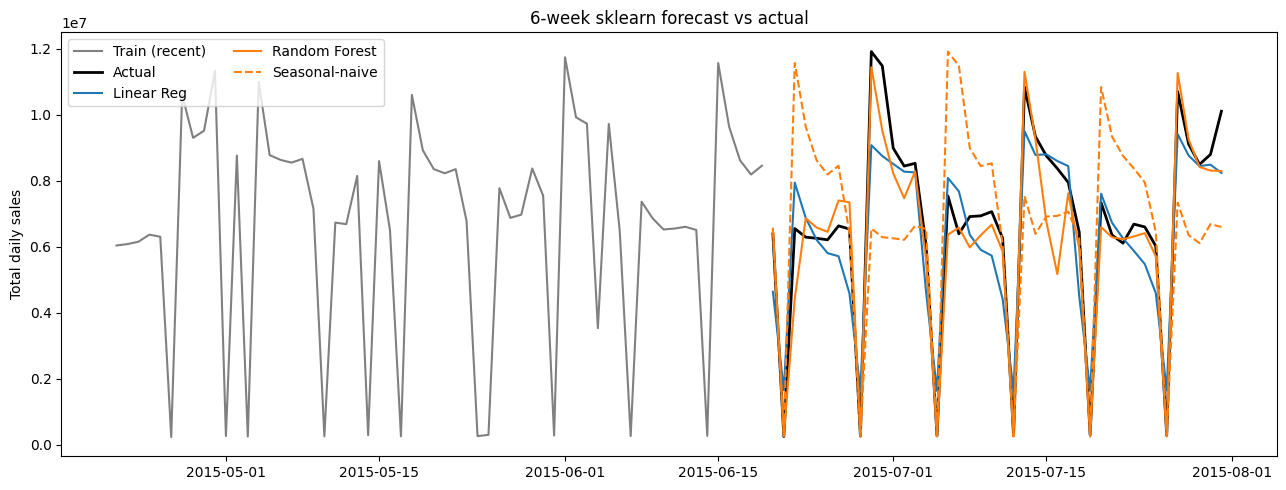

In [8]:
plt.figure(figsize=(13, 5))
ctx = train.iloc[-60:]
plt.plot(ctx["ds"], ctx["y"], color="gray", label="Train (recent)")
plt.plot(test["ds"], actual, color="black", lw=2, label="Actual")
plt.plot(test["ds"], lin_pred, label="Linear Reg")
plt.plot(test["ds"], rf_pred, label="Random Forest")
plt.plot(test["ds"], snaive_pred, ls="--", color="tab:orange", label="Seasonal-naive")
plt.title("6-week sklearn forecast vs actual")
plt.ylabel("Total daily sales"); plt.legend(ncol=2); plt.tight_layout(); plt.show()


Reading the four lines against the black actual line:

- **All of them nail the Sunday collapse** — every model catches the sharp weekly drop to near-zero with high accuracy, so the dominant weekly pattern is captured.
- **Seasonal-naive** is the loosest: on normal-revenue days it swings well above and below the actual line, over- and under-predicting by a lot. It only knows "same as last week", so any week-to-week change throws it off.
- **Linear Regression** is the smoothest. It never tracks the peaks tightly, but it also never strays far from actual, so it's a safe, low-variance forecast that rounds off the sharp movements.
- **Random Forest** is the closest to actual, following the ups and downs almost exactly. The one clear miss is a downward movement around 15 July, where it predicts well below the actual line. Apart from that it hugs the actual line closely, which is the visual version of its winning WAPE.

## 7. Recommendation

- **A `lag_7` + calendar + promo feature table lets standard regressors forecast six weeks of daily sales**, evaluated honestly against a seasonal-naive baseline. **Random Forest is the recommended model**, cutting the baseline's error to under a third (WAPE 30.2% → 8.9%).
- **Random Forest beats Linear Regression here for a structural reason, not by luck.** The EDA showed the promo lift collapses from +57% (Monday) to +22% (Friday), a strong promo × weekday interaction. A purely additive linear model cannot represent that, whatever the encoding; a tree ensemble learns it natively. That interaction, not the weekday encoding, is the real reason Random Forest wins.
- **Business use:** the six-week outlook supports inventory and staffing. Because `PromoShare` is an input feature, planners can simulate promo vs. non-promo weeks before committing to a campaign.
- **On metrics:** MAPE is reported in most tutorials but is invalid here — public-holiday closures create near-zero days that make it explode. WAPE gives an honest percentage.
- **Limitations:** this forecasts the company total, not individual stores (notebook 02 explains why total is the right target here). Accuracy rests on a single six-week window. Tree models can't extrapolate beyond their training range. The 2014 dip was a coverage effect (fewer stores reporting), not a real demand shift, so it needs no special correction beyond keeping the chronological split. Ways to address these are in Next steps below.
- **Cross-check:** the companion `04_forecasting_prophet` notebook reaches a similar accuracy with almost no feature engineering, which is a good independent check on these numbers.
- **On encoding:** notebook 02 recommended feeding weekday and month as categories, and I tested that. It turned out not to help the linear model, because `lag_7` (last week's same weekday) already encodes the weekly shape, so the one-hot weekday flags went to zero and the extra columns only added noise (one-hot WAPE 29.2% vs the integer model's 15.1%). A useful reminder that a "correct" encoding adds nothing when another feature already carries the signal.

## 8. Next steps

If I took this further, these are the directions I'd explore, roughly in order of expected payoff:

- **Model each store, not just the total.** This notebook forecasts the company-wide total, which is the right first target but hides store-level differences. A per-store model (or a hierarchical one that shares information across stores) would let planning happen at the store level, where inventory and staffing decisions are actually made.
- **Use the store metadata the raw dataset provides.** I only used sales, promo, and the calendar. Rossmann also ships `StoreType`, `Assortment`, `CompetitionDistance`, `Promo2`, and state/school-holiday flags. These are likely to explain a chunk of the day-to-day variation the current model treats as noise, especially the holiday spikes.
- **Add an explicit promo × weekday interaction to the linear model.** The EDA showed the promo lift is large early in the week and small on Fridays. A tree captures that for free; a linear model can't unless the interaction is written in as a feature. Adding it would test whether an interpretable linear model can close the gap to Random Forest.
- **Evaluate with rolling-origin cross-validation.** Every score here rests on a single six-week window, which could be lucky or unlucky. Re-forecasting from many cut-off dates and averaging the error would give a more trustworthy estimate of real-world accuracy.
- **Handle the near-zero days directly.** The biggest errors cluster on holidays and closure days. Flagging those explicitly (rather than letting the model average over them) would likely tighten the forecast where it's currently weakest.
- **Try gradient boosting.** Random Forest already wins here; a boosted-tree model (XGBoost or LightGBM) is worth trying as a stronger baseline, since it often edges out a random forest on structured tabular data like this.